# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


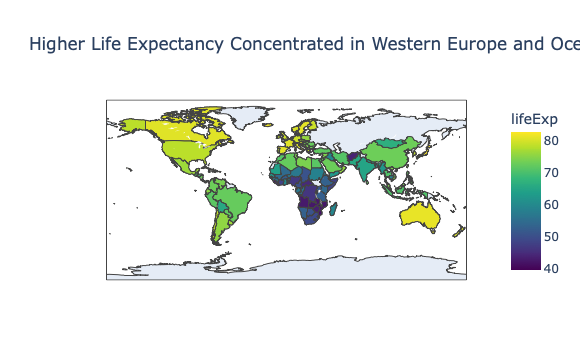

In [2]:
import pandas as pd
import plotly.express as px

# Load built-in gapminder dataset
df = px.data.gapminder()

# Filter for one year
df_2007 = df[df['year'] == 2007]

# Create choropleth map
fig = px.choropleth(
    df_2007,
    locations='iso_alpha',
    color='lifeExp',
    hover_name='country',
    color_continuous_scale='Viridis',
    title='Higher Life Expectancy Concentrated in Western Europe and Oceania (2007)'
)

fig.show()# Task 1


## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


In [9]:
import json
import pandas as pd
import plotly.express as px
import requests

# GeoJSON URL for German states
url = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json"

geojson = requests.get(url).json()

# Inspect GeoJSON properties
print(geojson['features'][0]['properties'])

{'id': 'DE-BW', 'name': 'Baden-Württemberg', 'type': 'State'}


In [7]:
df_states = pd.DataFrame({
    'state': [
        'Baden-Württemberg',
        'Bayern',
        'Berlin',
        'Brandenburg',
        'Bremen',
        'Hamburg',
        'Hessen',
        'Niedersachsen',
        'Nordrhein-Westfalen',
        'Sachsen'
    ],
    'unemployment_rate': [3.9, 3.5, 9.1, 5.8, 10.2, 6.3, 4.8, 5.4, 7.1, 5.9]
})

df_states

,state,unemployment_rate
0,Baden-Württemberg,3.9
1,Bayern,3.5
2,Berlin,9.1
3,Brandenburg,5.8
4,Bremen,10.2
5,Hamburg,6.3
6,Hessen,4.8
7,Niedersachsen,5.4
8,Nordrhein-Westfalen,7.1
9,Sachsen,5.9


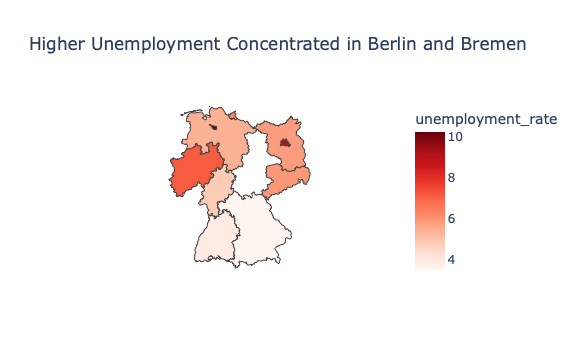

In [8]:
fig = px.choropleth(
    df_states,
    geojson=geojson,
    locations='state',
    featureidkey='properties.name',
    color='unemployment_rate',
    color_continuous_scale='Reds',
    projection='mercator',
    hover_name='state',
    title='Higher Unemployment Concentrated in Berlin and Bremen'
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()